In [6]:
import numpy as np
import pandas as pd

import os, sys

# find the folder that contains "idsia_mpc"
# In Jupyter, __file__ is not defined, so start from the current working directory
current_dir = os.getcwd()

while True:
    if os.path.exists(os.path.join(current_dir, "idsia_mpc")):
        PROJECT_ROOT = current_dir
        break
    parent = os.path.dirname(current_dir)
    if parent == current_dir:  # reached filesystem root
        raise RuntimeError("Could not find project root containing 'idsia_mpc'")
    current_dir = parent

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Using project root:", PROJECT_ROOT)

from idsia_mpc.control_engineering_practice.plot_utils import setup_matplotlib

Using project root: /home/rbusetto/nanodrone-sysid-mpc


In [7]:
setup_matplotlib()
type = "real"
traj_id = '1809'
traj_type = "melon"

# === File paths ===
import os
OUT_FOLDER = os.path.join(PROJECT_ROOT, "idsia_mpc", "control_engineering_practice", "sysid", "out")

file_phys = os.path.join(OUT_FOLDER, "predictions", type, "physics_model_multistep",
                         f"experiment_{traj_type}_{traj_id}.csv")
file_neur = os.path.join(OUT_FOLDER, "predictions", type, "neural_model_multistep",
                         f"experiment_{traj_type}_{traj_id}.csv")
file_res = os.path.join(OUT_FOLDER, "predictions", type, "residual_model_multistep",
                        f"experiment_{traj_type}_{traj_id}.csv")
file_base = os.path.join(OUT_FOLDER, "predictions", type, "baseline_model_multistep",
                         f"experiment_{traj_type}_{traj_id}.csv")


# file_phys = f'../out/predictions/{type}/physics_model_multistep/experiment_{traj_type}_{traj_id}.csv'
# file_neur = f'../out/predictions/{type}/neural_model_multistep/experiment_{traj_type}_{traj_id}.csv'
# file_res  = f'../out/predictions/{type}/residual_model_multistep/experiment_{traj_type}_{traj_id}.csv'
# file_base  = f'../out/predictions/{type}/baseline_model_multistep/experiment_{traj_type}_{traj_id}.csv'

# === Read CSVs ===
df_phys = pd.read_csv(file_phys)
df_neur = pd.read_csv(file_neur)
df_res  = pd.read_csv(file_res)
df_base = pd.read_csv(file_base)

print("✅ Loaded datasets:")
print(f"  Physics model:  {df_phys.shape}")
print(f"  Neural model:   {df_neur.shape}")
print(f"  Residual model: {df_res.shape}")
print(f"  Baseline model: {df_base.shape}")

✅ Loaded datasets:
  Physics model:  (2950, 625)
  Neural model:   (2950, 625)
  Residual model: (2950, 625)
  Baseline model: (2950, 625)


In [8]:
if type == "sim":
    print("\n=== 🔍 Consistency check: logged vs 1-step predicted ===")
    print(f"{'State':<8} | {'SumDiff':>12} | {'MeanDiff':>12} | {'RMSE':>12}")
    print("-"*45)
    state_names = ['x','y','z','roll','pitch','yaw','vx','vy','vz','wx','wy','wz']
    for name in state_names:
        diff = df_phys[name] - df_phys[f"{name}_pred_h1"]
        valid = diff[np.isfinite(diff)]  # ignore NaNs at the end
        sumdiff = valid.sum()
        meandiff = valid.mean()
        rmse = np.sqrt(np.mean(valid**2))
        print(f"{name:<8} | {sumdiff:>12.3e} | {meandiff:>12.3e} | {rmse:>12.3e}")

    print("-"*45)

In [9]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.ticker import FormatStrFormatter
#
# # --- Config ---
# horizon = 10
# N = 5000
# dt = np.mean(np.diff(df_phys["t"]))
# t_vec = df_phys["t"].to_numpy()
# num_samples = len(df_phys)
#
# # === Define states ===
# state_labels = [
#     ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
#     [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
#     [r'$v_x$ [m/s]', r'$v_y$ [m/s]', r'$v_z$ [m/s]'],
#     [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
# ]
# state_names = ['x','y','z','vx','vy','vz','roll','pitch','yaw','wx','wy','wz']
# state_indices = [
#     [0, 1, 2],   # position
#     [3, 4, 5],   # euler
#     [6, 7, 8],   # linear velocities
#     [9, 10, 11]  # angular velocities
# ]
#
# # === Colors and styles ===
# colors = {
#     "true": "red",
#     "phys": "tab:blue",
#     "neur": "tab:orange",
#     "res": "tab:green",
# }
# labels = {
#     "true": "GT",
#     "phys": "Physics",
#     "neur": "Neural",
#     "res": "Residual",
# }
#
# # === Precompute prediction tensors ===
# phys_multistep = {
#     name: np.stack([df_phys[f"{name}_pred_h{h+1}"].to_numpy() for h in range(horizon)], axis=1)
#     for name in state_names
# }
# neur_multistep = {
#     name: np.stack([df_neur[f"{name}_pred_h{h+1}"].to_numpy() for h in range(horizon)], axis=1)
#     for name in state_names
# }
# res_multistep = {
#     name: np.stack([df_res[f"{name}_pred_h{h+1}"].to_numpy() for h in range(horizon)], axis=1)
#     for name in state_names
# }
#
# # === Figure setup ===
# fig, axs = plt.subplots(4, 3, figsize=(16, 9), sharex=True, dpi=200)
#
# # === Plot each state ===
# for r in range(4):
#     for c in range(3):
#         idx = state_indices[r][c]
#         name = state_names[idx]
#         ax = axs[r, c]
#
#         # --- Rollout fans ---
#         for s in range(min(num_samples, N)):
#             rollout_time = df_phys["t"].iloc[s] + np.arange(horizon) * dt
#             valid = rollout_time < df_phys["t"].iloc[min(N, num_samples - 1)]
#
#             ax.plot(rollout_time[valid], phys_multistep[name][s, :np.sum(valid)],
#                     '-', color=colors["phys"], alpha=0.15, linewidth=1)
#             ax.plot(rollout_time[valid], neur_multistep[name][s, :np.sum(valid)],
#                     '-', color=colors["neur"], alpha=0.15, linewidth=1)
#             ax.plot(rollout_time[valid], res_multistep[name][s, :np.sum(valid)],
#                     '-', color=colors["res"], alpha=0.15, linewidth=1)
#
#         # --- Ground truth & 1-step predictions ---
#         ax.plot(t_vec[:N], phys_multistep[name][:N, 0], '-', color=colors["phys"], linewidth=1.2, label=f"{labels['phys']} – 1-step")
#         ax.plot(t_vec[:N], neur_multistep[name][:N, 0], '-', color=colors["neur"], linewidth=1.2, label=f"{labels['neur']} – 1-step")
#         ax.plot(t_vec[:N], res_multistep[name][:N, 0], '-', color=colors["res"], linewidth=1.2, label=f"{labels['res']} – 1-step")
#         ax.plot(t_vec[:N], df_phys[name][:N], '--', color=colors["true"], linewidth=1, label=labels["true"])
#
#         ax.set_ylabel(state_labels[r][c])
#         ax.grid(True, alpha=0.3)
#         ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
#
# fig.text(0.5, 0.03, "Time [s]", ha='center', va='center', fontsize=14)
#
# # === Global legend ===
# handles, lbls = [], []
# for ax in axs.flat:
#     h, l = ax.get_legend_handles_labels()
#     for handle, label in zip(h, l):
#         if label not in lbls:
#             handles.append(handle)
#             lbls.append(label)
# fig.legend(handles, lbls, loc='upper center', ncols=4, bbox_to_anchor=(0.5, 1.0), fontsize=11)
#
# plt.subplots_adjust(top=0.92, bottom=0.08, hspace=0.15, wspace=0.3)
# plt.show()
#
# # --- Optional ---
# # fig.savefig("comparison_multistate_rollouts.png", dpi=300, bbox_inches="tight")

NameError: name 'df_phys' is not defined

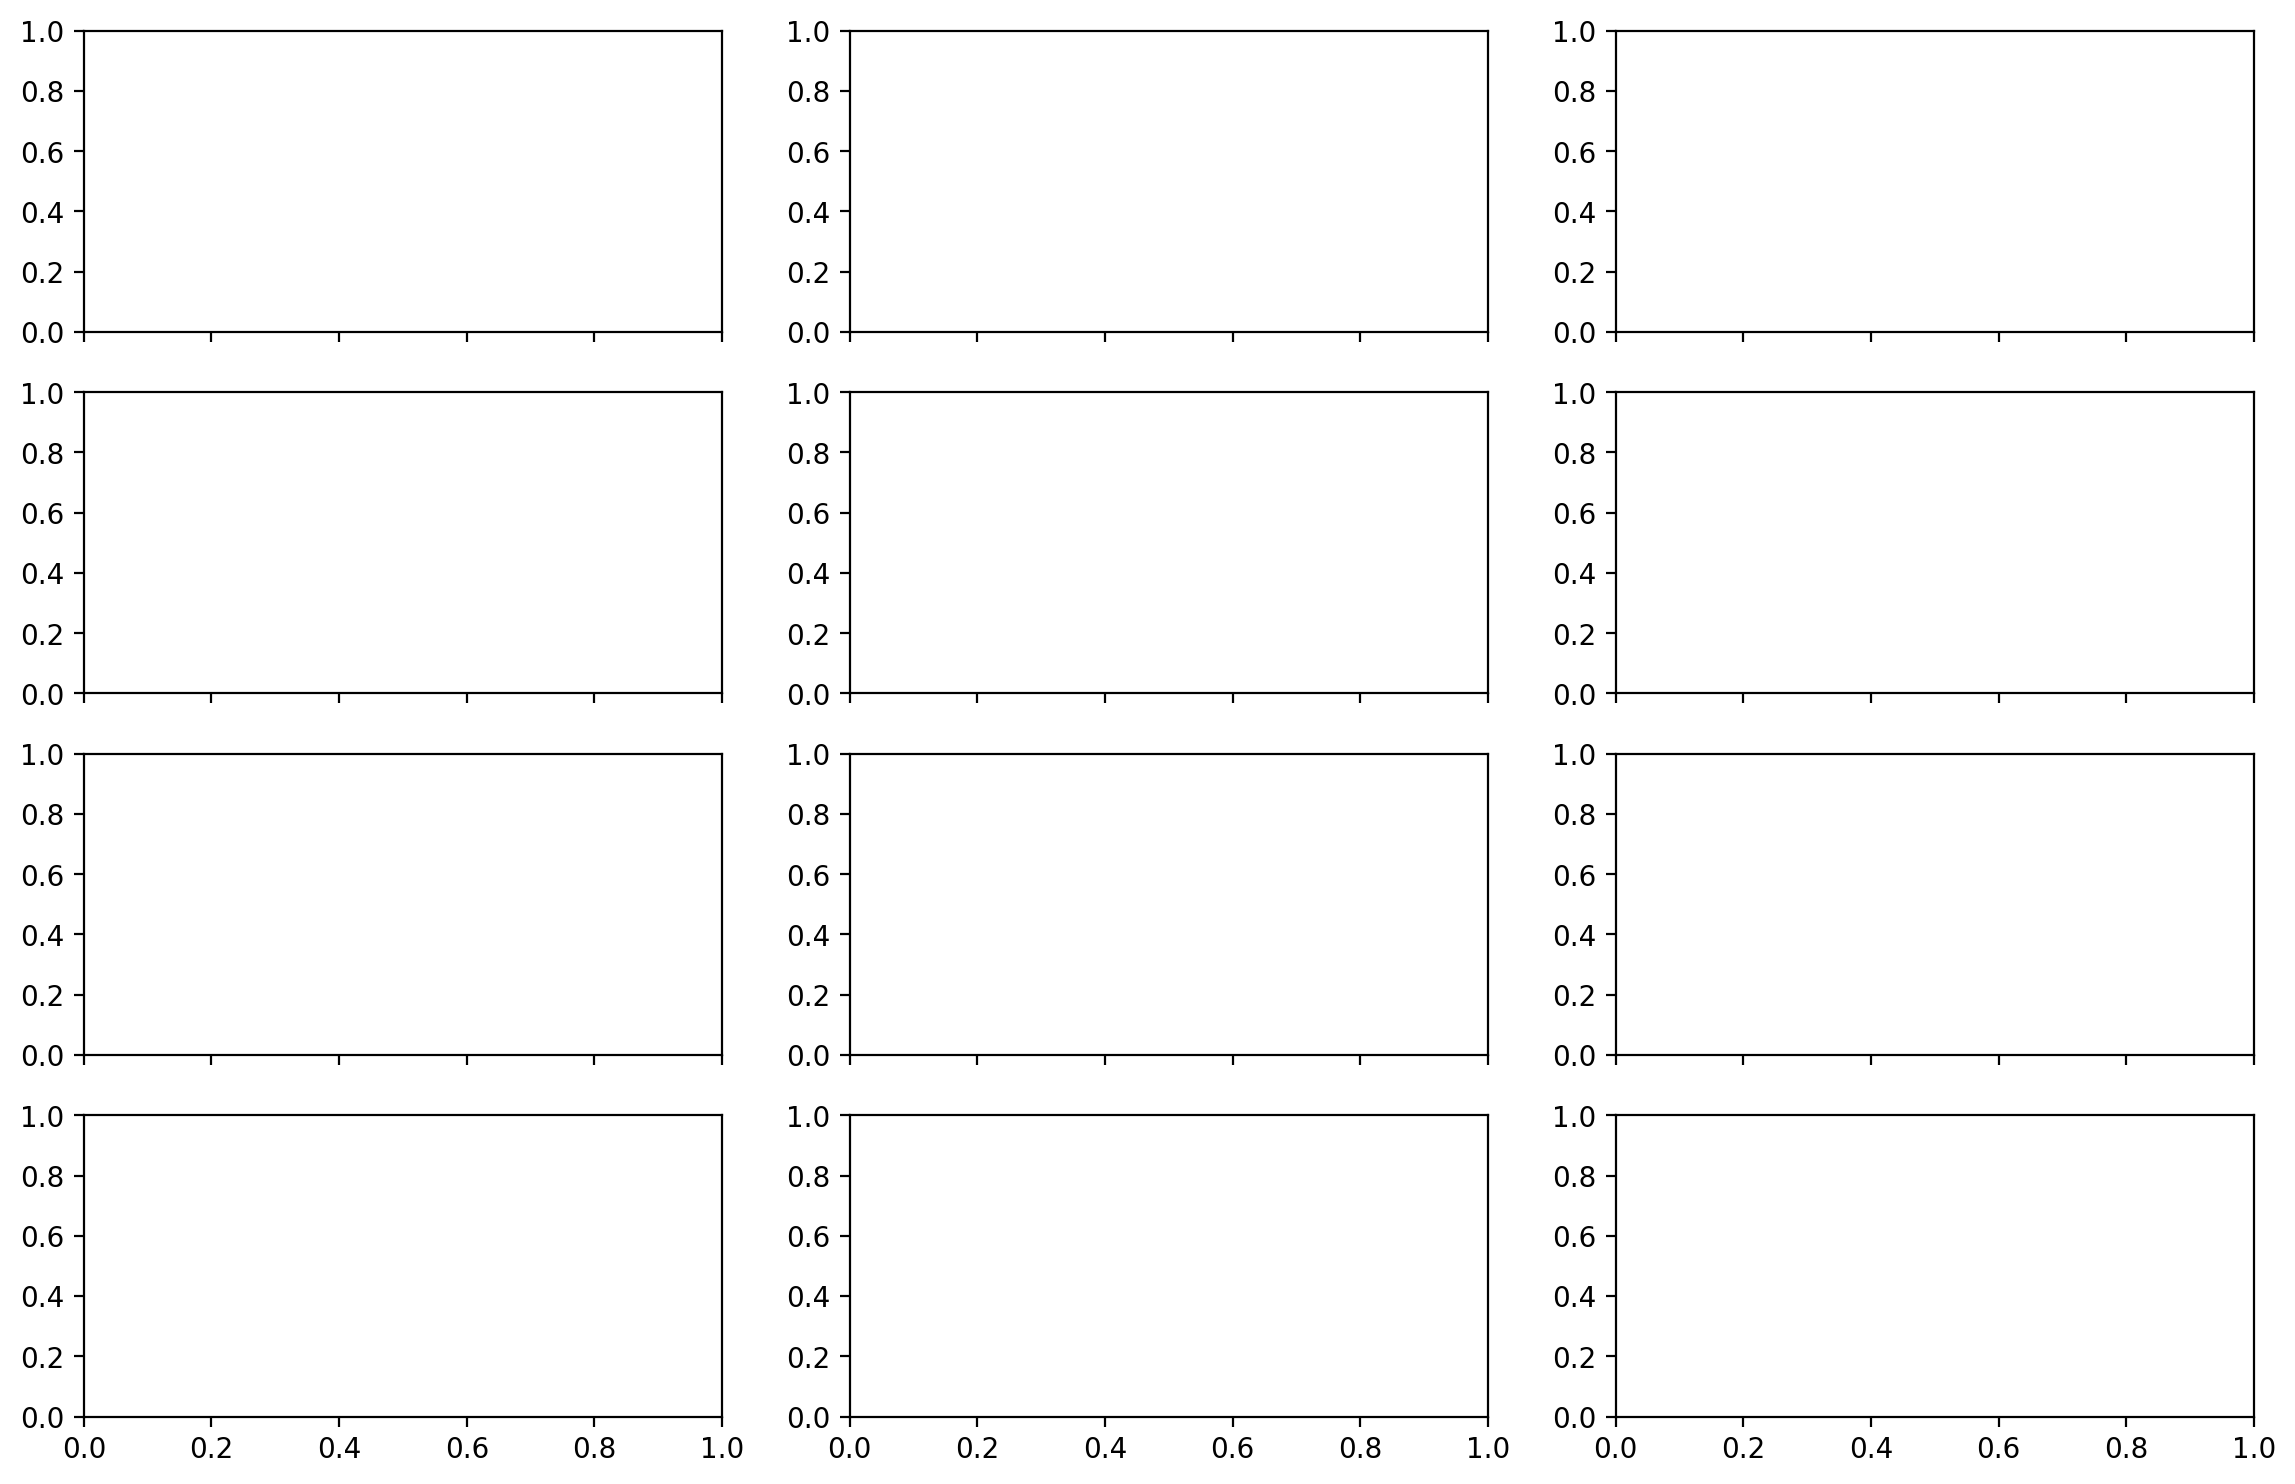

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
max_horizon = 50
use_log_y = False  # set True if you want log-scale RMSE

state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
    [r'$v_x$ [m/s]', r'$v_y$ [m/s]', r'$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]
state_names = ['x','y','z','roll','pitch','yaw','vx','vy','vz','wx','wy','wz']

# --- Helper to compute horizon RMSE ---
def compute_horizon_errors(df, state, max_horizon):
    means, rmses = [], []
    for h in range(1, max_horizon + 1):
        col = f"{state}_pred_h{h}"
        if col not in df.columns:
            continue
        err = df[state].shift(-h + 1) - df[col]
        err = err.dropna()
        means.append(err.mean())
        rmses.append(np.sqrt(np.mean(err**2)))
    return np.arange(1, len(rmses) + 1), np.array(means), np.array(rmses)

# --- Figure setup ---
fig, axs = plt.subplots(4, 3, figsize=(14, 9), sharex=True, dpi=200)

for r in range(4):
    for c in range(3):
        idx = r * 3 + c
        if idx >= len(state_names):
            continue
        state = state_names[idx]
        ax = axs[r, c]

        # --- Compute errors for each model ---
        h_phys, _, rmse_phys = compute_horizon_errors(df_phys, state, max_horizon)
        h_neur, _, rmse_neur = compute_horizon_errors(df_neur, state, max_horizon)
        h_res,  _, rmse_res  = compute_horizon_errors(df_res,  state, max_horizon)
        h_base, _, rmse_base = compute_horizon_errors(df_base, state, max_horizon)

        # --- Plot ---
        ax.plot(h_phys, rmse_phys, 'o--', color='tab:blue',  label='Physics',  markersize=3, linewidth=1)
        ax.plot(h_neur, rmse_neur, 's--', color='tab:orange', label='Neural',   markersize=3, linewidth=1)
        ax.plot(h_res,  rmse_res,  'D--', color='tab:green',  label='Residual', markersize=3, linewidth=1)
        ax.plot(h_base, rmse_base, '*-',  color='tab:red',    label='Baseline', markersize=5, linewidth=1)

        ax.set_ylabel(state_labels[r][c])
        ax.grid(True, alpha=0.3)
        if use_log_y:
            ax.set_yscale('log')
        else:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

# --- Common axis labels ---
fig.text(0.5, 0.03, "Prediction Horizon [steps]", ha='center', fontsize=18)
fig.text(0.04, 0.5, "RMSE", va='center', rotation='vertical', fontsize=18)

# --- Global legend ---
handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='upper center', ncols=4, bbox_to_anchor=(0.5, 1.0), fontsize=18)

plt.subplots_adjust(top=0.92, bottom=0.1, hspace=0.25, wspace=0.3)
plt.show()
